# Part 1 — Joint Motivation x Sentiment Structure

Understand how `parent_motivation` and `highlight_sentiment` co-occur, and how motivation
relates to model strategy and parent demographics.

- **1a** — Motivation x sentiment heatmap (confirms sentiment-neutrality of motivation codes)
- **1b** — Box + strip plots: sentiment per motivation code
- **1c** — Motivation x model_strategy crosstab + chi-squared
- **1d** — Motivation x key demographics (parent_gender, parenting_style, genai_familiarity)

**Data:** 294 rows with non-null `parent_motivation` (filtered from 404-row df_sel).  
Sparse motivation codes (n<5) pooled into `Other` for all analyses.

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from pathlib import Path

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK.')

Imports OK.


In [9]:
DATA_DIR   = Path('../data-exports/20260412_183830')
OUTPUT_DIR = DATA_DIR / 'highlight_analysis_output'
OUTPUT_DIR.mkdir(exist_ok=True)

# Sentiment scores + scenario metadata + demographics from df_sel
df_sel = pd.read_csv(OUTPUT_DIR / 'df_sel.csv')
OVERALL_MEAN = df_sel['highlight_sentiment'].dropna().mean()

# Motivation + strategy codes from R5_highlights_coded (source of truth)
# R5_highlights_coded is a sibling of highlight_analysis_output under 20260412_183830/
r5 = pd.read_csv(DATA_DIR / 'R5_highlights_coded', sep='\t')
r5.columns = r5.columns.str.strip()
r5 = r5.rename(columns={
    'highlight_id':      'selection_id',
    'Parent Motivation': 'parent_motivation',
    'Model Strategy':    'model_strategy',
})
r5 = r5[r5['selection_id'].notna() & (r5['selection_id'].astype(str).str.strip() != '')]

# Normalize typo: "Strong Emotion" -> "Strong Emotions"
r5['parent_motivation'] = r5['parent_motivation'].replace(
    'Response Could Evoke Strong Emotion', 'Response Could Evoke Strong Emotions'
)

# Deduplicate: some highlights appear multiple times (duplicate export rows)
r5_dedup = r5.drop_duplicates(subset='selection_id', keep='first')

# Override motivation + strategy in df_sel with R5 values
df_sel = df_sel.drop(columns=['parent_motivation', 'model_strategy'], errors='ignore')
df_sel = df_sel.merge(
    r5_dedup[['selection_id', 'parent_motivation', 'model_strategy']],
    on='selection_id', how='left'
)

# Filter to non-null motivation + sentiment
df = df_sel[
    df_sel['parent_motivation'].notna() & df_sel['highlight_sentiment'].notna()
].copy()

# Pool sparse motivation codes (n < 5) into 'Other'
motiv_counts = df['parent_motivation'].value_counts()
sparse_codes  = motiv_counts[motiv_counts < 5].index.tolist()
df['motivation_pooled'] = df['parent_motivation'].apply(
    lambda x: 'Other' if x in sparse_codes else x
)

print(f'df_sel total: {len(df_sel)} rows')
print(f'Non-null motivation + sentiment: {len(df)} rows')
if sparse_codes:
    print(f'Pooled into Other: {sparse_codes}')
print(f'\nMotivation code distribution (pooled):')
display(df['motivation_pooled'].value_counts())

df_sel total: 267 rows
Non-null motivation + sentiment: 264 rows

Motivation code distribution (pooled):


motivation_pooled
Response Usefulness                          94
Response Risk Awareness                      50
Response Could Evoke Strong Emotions         50
Child Intentions                             19
Response Identification of the Root Cause    16
Response Organization                        16
Response Complexity                          13
Response Confirmation / Contradiction         6
Name: count, dtype: int64

In [10]:
def cramers_v_from_ct(ct):
    """Chi-squared, p, dof, Cramer's V from a contingency table DataFrame."""
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    return chi2, p, dof, v

## 1a — Motivation x Sentiment Heatmap

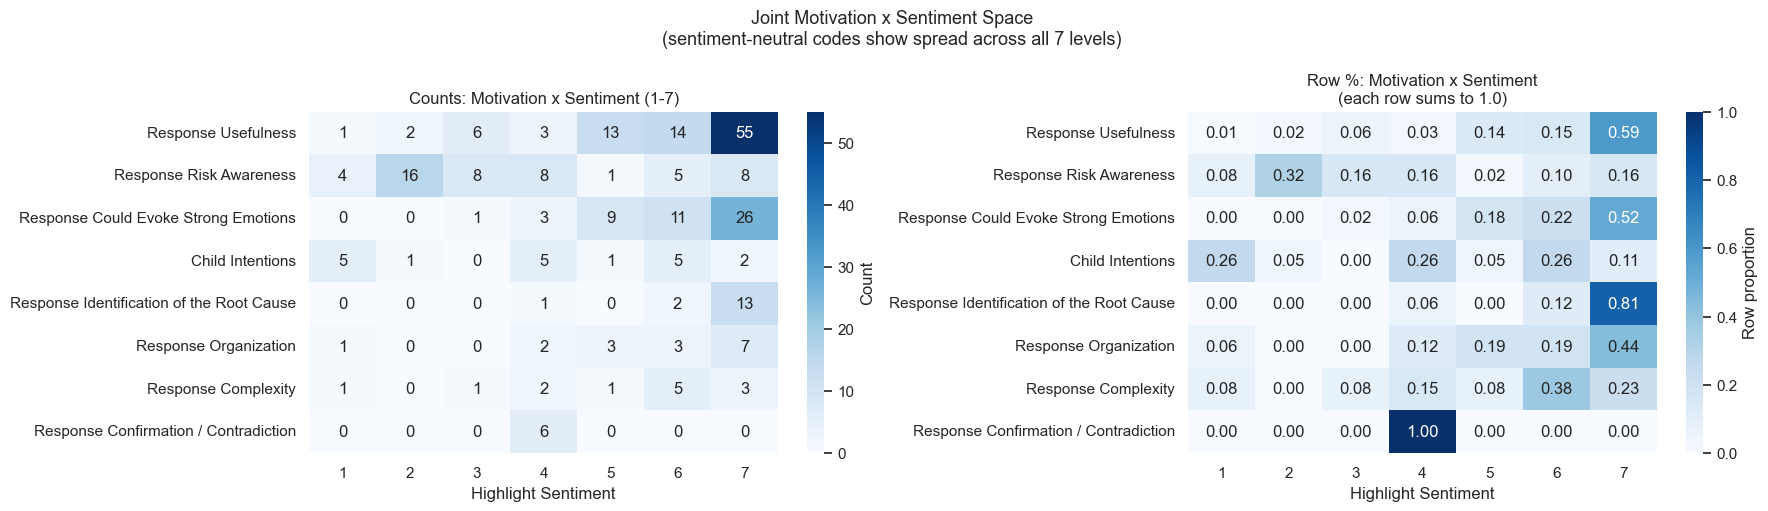

In [11]:
motiv_order = df['motivation_pooled'].value_counts().index.tolist()

ct = pd.crosstab(df['motivation_pooled'], df['highlight_sentiment'].astype(int))
ct = ct.reindex(motiv_order)
for col in range(1, 8):
    if col not in ct.columns:
        ct[col] = 0
ct = ct[[1, 2, 3, 4, 5, 6, 7]]
ct_pct = ct.div(ct.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, max(4, len(motiv_order) * 0.65)))

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Counts: Motivation x Sentiment (1-7)')
axes[0].set_xlabel('Highlight Sentiment')
axes[0].set_ylabel('')

sns.heatmap(ct_pct.round(2), annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            vmin=0, vmax=1, cbar_kws={'label': 'Row proportion'})
axes[1].set_title('Row %: Motivation x Sentiment\n(each row sums to 1.0)')
axes[1].set_xlabel('Highlight Sentiment')
axes[1].set_ylabel('')

fig.suptitle(
    'Joint Motivation x Sentiment Space\n'
    '(sentiment-neutral codes show spread across all 7 levels)',
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'motivation_x_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 1b — Box + Strip Plots: Sentiment per Motivation Code

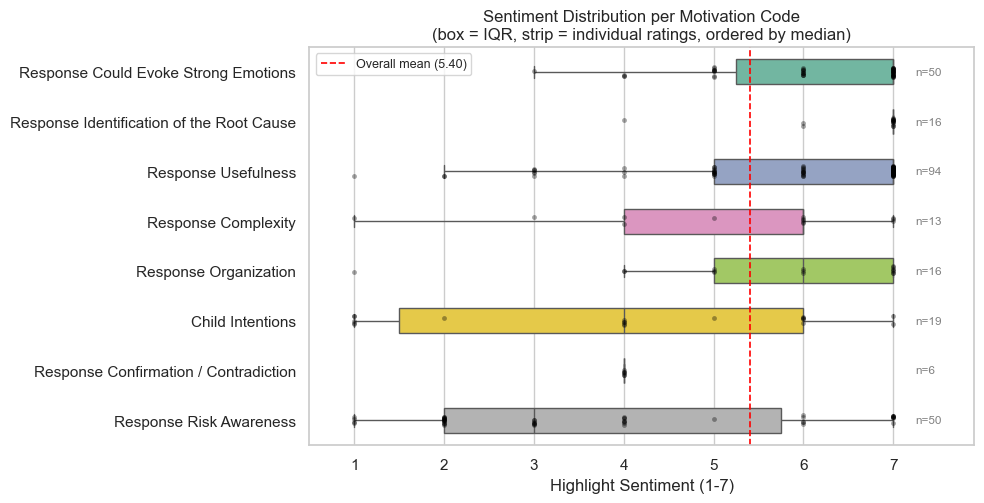

In [12]:
motiv_box_order = (
    df.groupby('motivation_pooled')['highlight_sentiment']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, max(5, len(motiv_box_order) * 0.65)))
sns.boxplot(
    data=df, x='highlight_sentiment', y='motivation_pooled',
    order=motiv_box_order, palette='Set2', width=0.5, fliersize=0, ax=ax
)
sns.stripplot(
    data=df, x='highlight_sentiment', y='motivation_pooled',
    order=motiv_box_order, color='black', alpha=0.35, size=3.5, jitter=True, ax=ax
)
ax.axvline(OVERALL_MEAN, color='red', linestyle='--', lw=1.2,
           label=f'Overall mean ({OVERALL_MEAN:.2f})')
for i, code in enumerate(motiv_box_order):
    n = df[df['motivation_pooled'] == code].shape[0]
    ax.text(7.25, i, f'n={n}', va='center', fontsize=8.5, color='gray')
ax.set_xlim(0.5, 7.9)
ax.set_xlabel('Highlight Sentiment (1-7)')
ax.set_ylabel('')
ax.set_title('Sentiment Distribution per Motivation Code\n(box = IQR, strip = individual ratings, ordered by median)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_by_motivation_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 1c — Motivation x Model Strategy

Rows with both motivation and strategy: 242

Chi-squared: 216.26  df=60  p=0.0000
Cramer's V: 0.386  (N=242)

Counts:


model_strategy,Clarify Child's Intent,Consider Age Group,Defer to Resources,Emphasize Emotional Support,Emphasize Risk Awareness,Encourage Introspection,Explain Problems in Prompt,Prompted Suggestions,Redirect with Alternatives,Refuse Response and Explain,Unprompted Suggestions
motivation_pooled,,,,,,,,,,,
Response Complexity,0,3,0,0,0,0,0,9,0,0,0
Response Confirmation / Contradiction,0,2,0,0,0,0,1,3,0,0,0
Response Could Evoke Strong Emotions,3,5,0,29,0,1,6,5,1,0,0
Response Identification of the Root Cause,0,0,0,4,1,0,1,5,2,0,3
Response Organization,4,0,0,0,0,1,0,11,0,0,0
Response Risk Awareness,3,2,0,8,14,3,2,13,0,0,5
Response Usefulness,8,4,2,6,2,0,0,43,19,5,3



Row % (motivation -> strategy distribution):


model_strategy,Clarify Child's Intent,Consider Age Group,Defer to Resources,Emphasize Emotional Support,Emphasize Risk Awareness,Encourage Introspection,Explain Problems in Prompt,Prompted Suggestions,Redirect with Alternatives,Refuse Response and Explain,Unprompted Suggestions
motivation_pooled,,,,,,,,,,,
Response Complexity,0.000,0.250,0.000,0.000,0.000,0.000,0.000,0.750,0.000,0.000,0.000
Response Confirmation / Contradiction,0.000,0.333,0.000,0.000,0.000,0.000,0.167,0.500,0.000,0.000,0.000
Response Could Evoke Strong Emotions,0.060,0.100,0.000,0.580,0.000,0.020,0.120,0.100,0.020,0.000,0.000
Response Identification of the Root Cause,0.000,0.000,0.000,0.250,0.062,0.000,0.062,0.312,0.125,0.000,0.188
Response Organization,0.250,0.000,0.000,0.000,0.000,0.062,0.000,0.688,0.000,0.000,0.000
Response Risk Awareness,0.060,0.040,0.000,0.160,0.280,0.060,0.040,0.260,0.000,0.000,0.100
Response Usefulness,0.087,0.043,0.022,0.065,0.022,0.000,0.000,0.467,0.207,0.054,0.033



Saved: motivation_x_strategy_crosstab.csv, motivation_x_strategy_crosstab_pct.csv


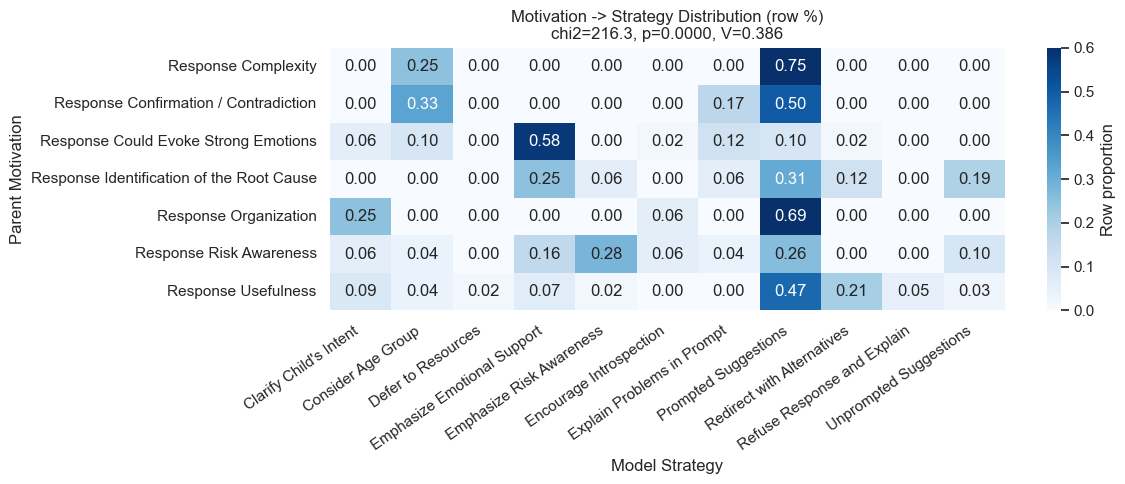

In [13]:
df_both = df[df['model_strategy'].notna()].copy()
print(f'Rows with both motivation and strategy: {len(df_both)}')

ct_ms = pd.crosstab(df_both['motivation_pooled'], df_both['model_strategy'])
chi2, p, dof, v = cramers_v_from_ct(ct_ms)
n = int(ct_ms.values.sum())
print(f'\nChi-squared: {chi2:.2f}  df={dof}  p={p:.4f}')
print(f"Cramer's V: {v:.3f}  (N={n})")

print('\nCounts:')
display(ct_ms)

ct_ms_pct = ct_ms.div(ct_ms.sum(axis=1), axis=0)
print('\nRow % (motivation -> strategy distribution):')
display(ct_ms_pct.round(3))

ct_ms.to_csv(OUTPUT_DIR / 'motivation_x_strategy_crosstab.csv')
ct_ms_pct.round(3).to_csv(OUTPUT_DIR / 'motivation_x_strategy_crosstab_pct.csv')
print('\nSaved: motivation_x_strategy_crosstab.csv, motivation_x_strategy_crosstab_pct.csv')

fig, ax = plt.subplots(figsize=(max(12, ct_ms.shape[1] * 1.0), max(5, ct_ms.shape[0] * 0.65)))
sns.heatmap(ct_ms_pct.round(2), annot=True, fmt='.2f', cmap='Blues', ax=ax,
            vmin=0, vmax=0.6, cbar_kws={'label': 'Row proportion'})
ax.set_title(
    f'Motivation -> Strategy Distribution (row %)\n'
    f'chi2={chi2:.1f}, p={p:.4f}, V={v:.3f}'
)
ax.set_xlabel('Model Strategy')
ax.set_ylabel('Parent Motivation')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'motivation_x_strategy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 1d — Motivation x Key Demographics


--- parent_gender ---
chi2=26.19  df=7  p=0.0005  V=0.315  N=264


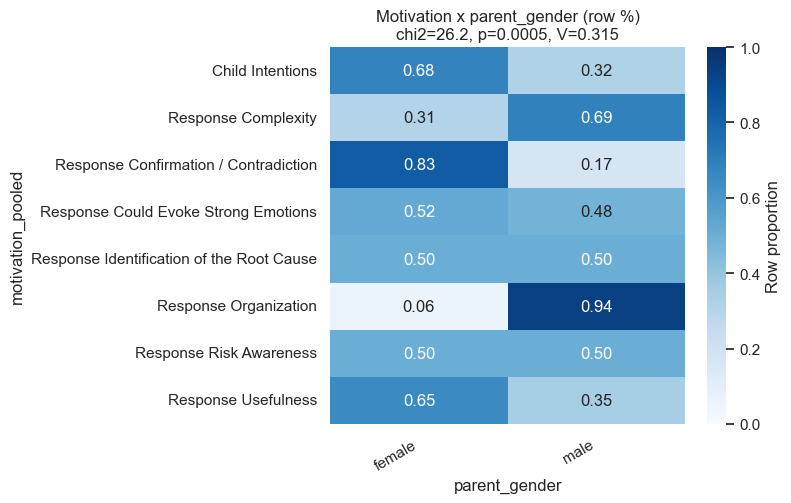


--- parenting_style ---
chi2=71.86  df=21  p=0.0000  V=0.257  N=364


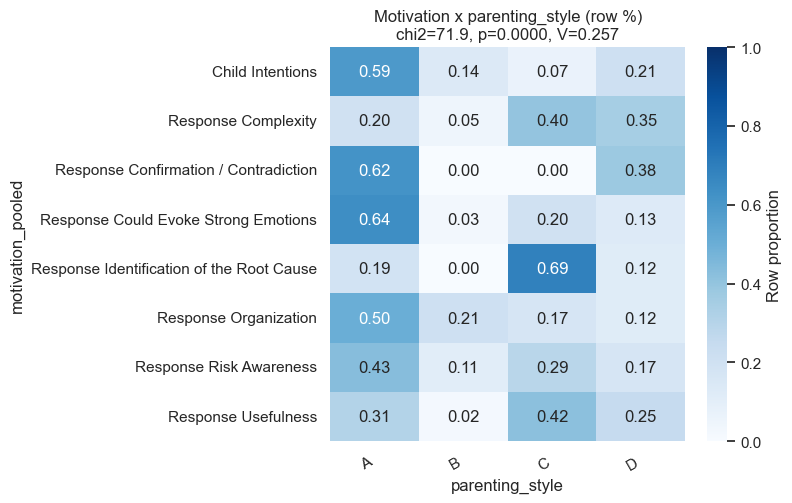


--- genai_familiarity ---
chi2=18.41  df=7  p=0.0103  V=0.264  N=264


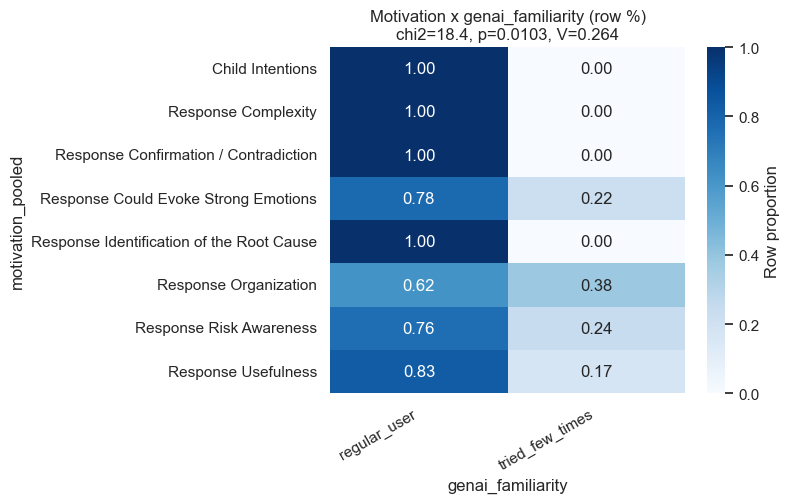


=== Summary: Motivation x Demographics ===


,demographic,chi2,p,cramers_v,n
0,parent_gender,26.19,0.0005,0.315,264
2,genai_familiarity,18.41,0.0103,0.264,264
1,parenting_style,71.86,0.0000,0.257,364


In [14]:
DEMO_COLS = ['parent_gender', 'parenting_style', 'genai_familiarity']

summary_rows = []
for demo in DEMO_COLS:
    if demo not in df.columns:
        print(f'Skipping {demo}: column not found')
        continue

    df_demo = df.copy()

    # parenting_style is semicolon-separated — explode to one row per style
    if demo == 'parenting_style':
        df_demo = (
            df_demo
            .assign(parenting_style=df_demo['parenting_style'].str.split(';'))
            .explode('parenting_style')
        )
        df_demo['parenting_style'] = df_demo['parenting_style'].str.strip()

    df_demo = df_demo[
        df_demo[demo].notna() & (df_demo[demo].astype(str).str.strip() != '')
    ]
    if df_demo[demo].nunique() < 2:
        print(f'Skipping {demo}: fewer than 2 levels')
        continue

    ct = pd.crosstab(df_demo['motivation_pooled'], df_demo[demo])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue

    chi2, p, dof, v = cramers_v_from_ct(ct)
    n = int(ct.values.sum())
    summary_rows.append({'demographic': demo, 'chi2': round(chi2, 2),
                          'p': round(p, 4), 'cramers_v': round(v, 3), 'n': n})

    print(f'\n--- {demo} ---')
    print(f'chi2={chi2:.2f}  df={dof}  p={p:.4f}  V={v:.3f}  N={n}')

    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    fig, ax = plt.subplots(
        figsize=(max(8, ct.shape[1] * 1.4), max(4, ct.shape[0] * 0.65))
    )
    sns.heatmap(ct_pct.round(2), annot=True, fmt='.2f', cmap='Blues', ax=ax,
                vmin=0, vmax=1, cbar_kws={'label': 'Row proportion'})
    ax.set_title(f'Motivation x {demo} (row %)\nchi2={chi2:.1f}, p={p:.4f}, V={v:.3f}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'motivation_x_{demo}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('\n=== Summary: Motivation x Demographics ===')
if summary_rows:
    display(pd.DataFrame(summary_rows).sort_values('cramers_v', ascending=False))